# One-stage learned annulus router

This notebook evaluates a direct gradient-to-mask mixture-of-experts model. A general one-stage decoder and an annulus specialist both receive raw gradient features. A learned router predicts whether the annulus expert should be used. Shape labels supervise the router during training only; test-time routing uses model features and never reads the true test shape.

Training and test noise levels are `0.0`, `0.001`, `0.0025`, `0.005`, and `0.01`.

## Architecture and losses

The model produces a soft mixture:

`mixed_logits = (1 - p_annulus) * general_logits + p_annulus * annulus_logits`

Training combines BCE+Dice on the mixed prediction, an annulus-expert mask loss on annulus examples, and weighted BCE for the router. Positive router weighting compensates for annuli representing only 10% of the training distribution. The boundary-weighted condition is compared separately from the unweighted router.

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from config import OneModelRunConfig, Stage2ModelConfig, StageTrainingConfig
from datasets import build_two_stage_datasets
from experiments import evaluate_noise_sweep, layer_table, parameter_count, save_noise_results, sigma_label
from experiments.notebook import plot_history, plot_noise_curve, plot_shape_curves
from models import select_best_stage2_threshold
from models.one_model import AnnulusRouterOneStage, fit_annulus_router, predict_annulus_router

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT = ROOT / 'output' / 'one_stage_annulus_router'
OUTPUT.mkdir(parents=True, exist_ok=True)
TRAIN_SIGMAS = (0.0, 0.001, 0.0025, 0.005, 0.01)
TEST_SIGMAS = TRAIN_SIGMAS
CONDITIONS = {'learned_router': 1.0, 'learned_router_weighted': 2.0}
RUN_TRAINING = False  # Missing checkpoints automatically trigger training.

def make_config(train_sigma, condition):
    return OneModelRunConfig(
        N=10, training_samples=10_000, validation_samples=1_000, test_samples=1_000,
        noise_sigma=train_sigma, noise_mode='absolute', seed=42, training_noise_replicas=1,
        training_shape_weights=(('rectangle', 0.25), ('two_circles', 0.45), ('annulus', 0.10),
                                ('ellipse', 0.15), ('circle', 0.05)),
        use_validation_threshold_sweep=True,
        model=Stage2ModelConfig(
            hidden_layer_sizes=(512, 1024), dropout_rates=(0.1, 0.1), model_type='coord_conv_decoder',
            latent_grid_size=16, latent_channels=160, decoder_channels=(160, 128, 96, 64, 32),
            training=StageTrainingConfig(epochs=120, batch_size=96, learning_rate=0.0005,
                validation_frequency=20, verbose=False, early_stopping_patience=20, min_epochs=40,
                min_improvement=0.001, lr_drop_factor=0.5, lr_drop_period=60,
                weight_decay=0.00025, gradient_clip_norm=1.0)),
        output_dir=OUTPUT / 'training_noise_test' / f'train_sigma{sigma_label(train_sigma)}' / condition,
    )

def make_model(config):
    return AnnulusRouterOneStage(
        input_dim=config.gradient_feature_size, output_dim=config.mask_pixels,
        hidden_dims=(512, 1024), dropout_rates=(0.1, 0.1), latent_grid_size=16,
        latent_channels=160, decoder_channels=(160, 128, 96, 64, 32),
    )

model_check = make_model(make_config(0.001, 'learned_router'))
print('Device:', DEVICE, 'parameters:', parameter_count(model_check))
architecture = layer_table(model_check, torch.zeros(2, 22))
architecture.to_csv(OUTPUT / 'architecture_layers.csv', index=False)
display(architecture)

Device: cuda parameters: {'total': 86246279, 'trainable': 86246279}


,layer,type,output_shape,parameters,trainable
0,general_expert.projection.0,Linear,"(2, 512)",11776,11776
1,general_expert.projection.1,ReLU,"(2, 512)",0,0
2,general_expert.projection.2,Dropout,"(2, 512)",0,0
3,general_expert.projection.3,Linear,"(2, 1024)",525312,525312
4,general_expert.projection.4,ReLU,"(2, 1024)",0,0
5,general_expert.projection.5,Dropout,"(2, 1024)",0,0
6,general_expert.projection.6,Linear,"(2, 40960)",41984000,41984000
7,general_expert.decoder.0,Conv2d,"(2, 160, 16, 16)",230560,230560
8,general_expert.decoder.1,BatchNorm2d,"(2, 160, 16, 16)",320,320
9,general_expert.decoder.2,ReLU,"(2, 160, 16, 16)",0,0



=== train sigma=0, condition=learned_router ===


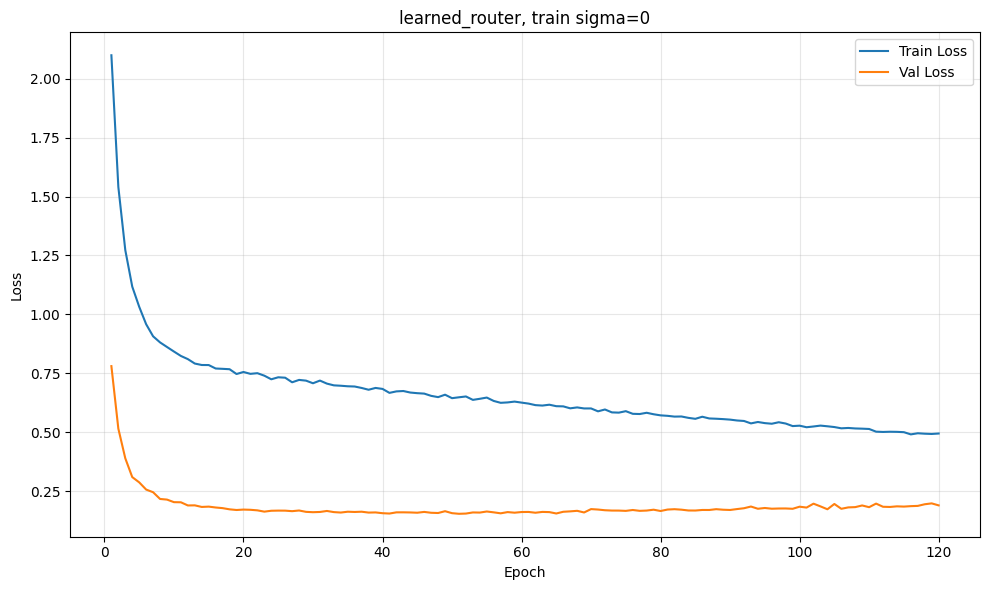

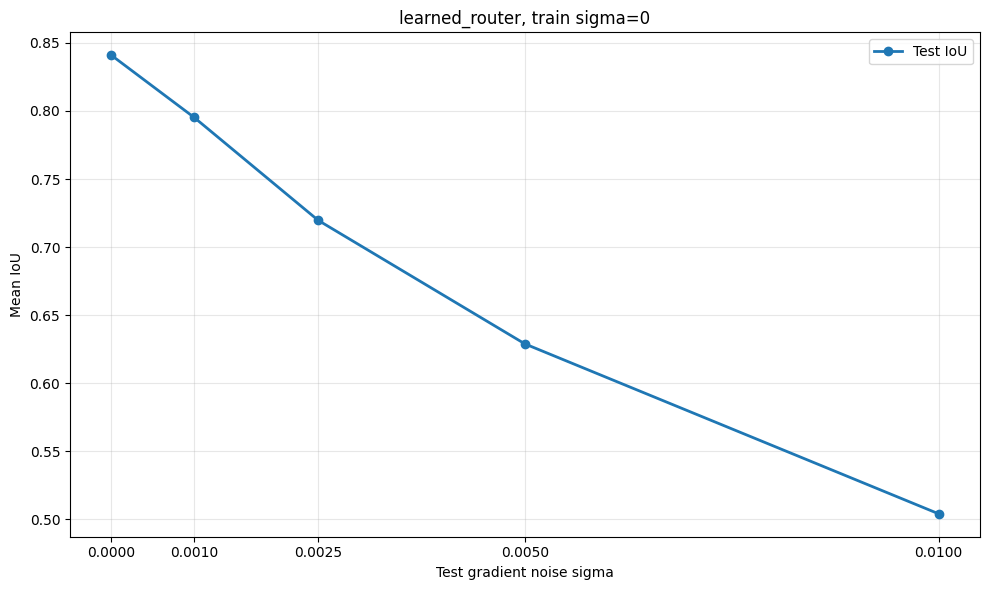

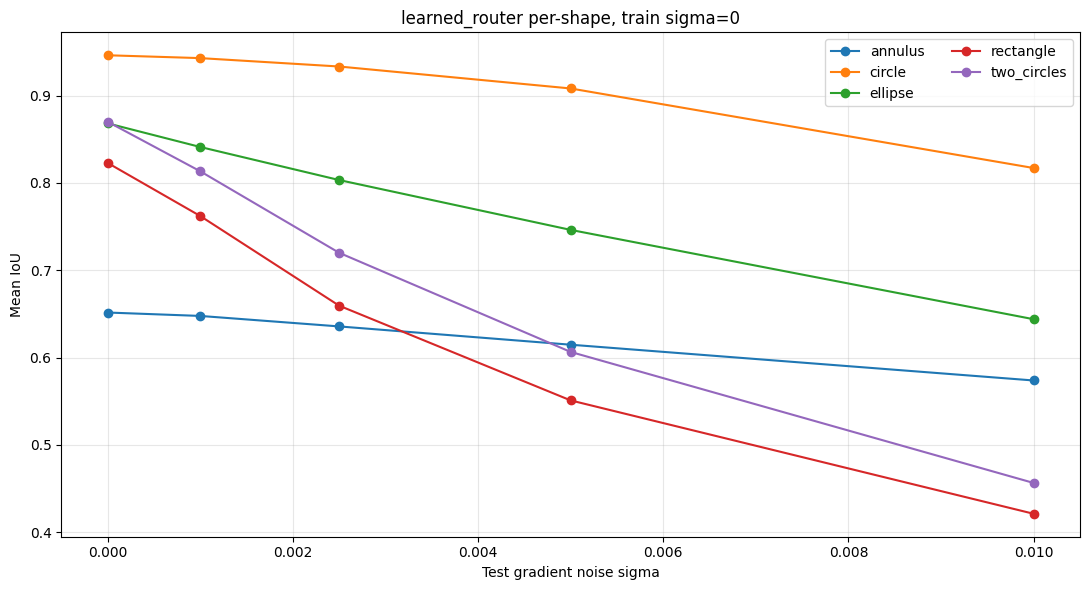


=== train sigma=0, condition=learned_router_weighted ===


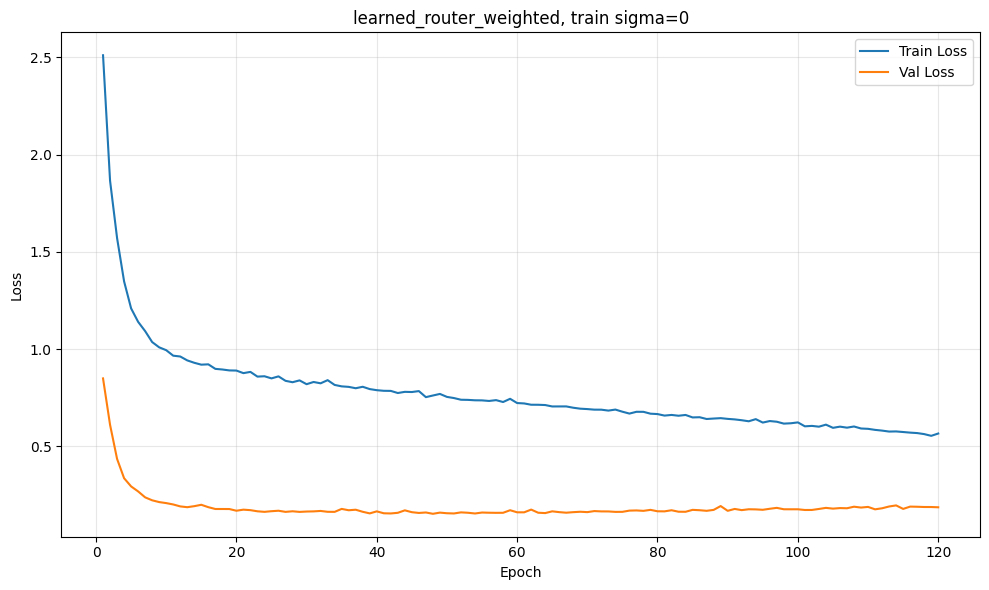

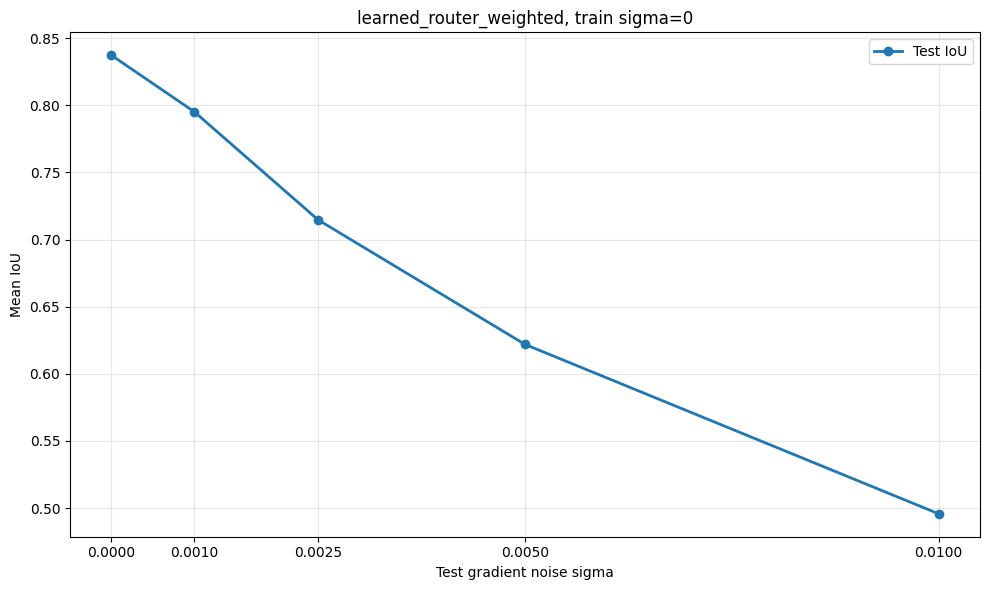

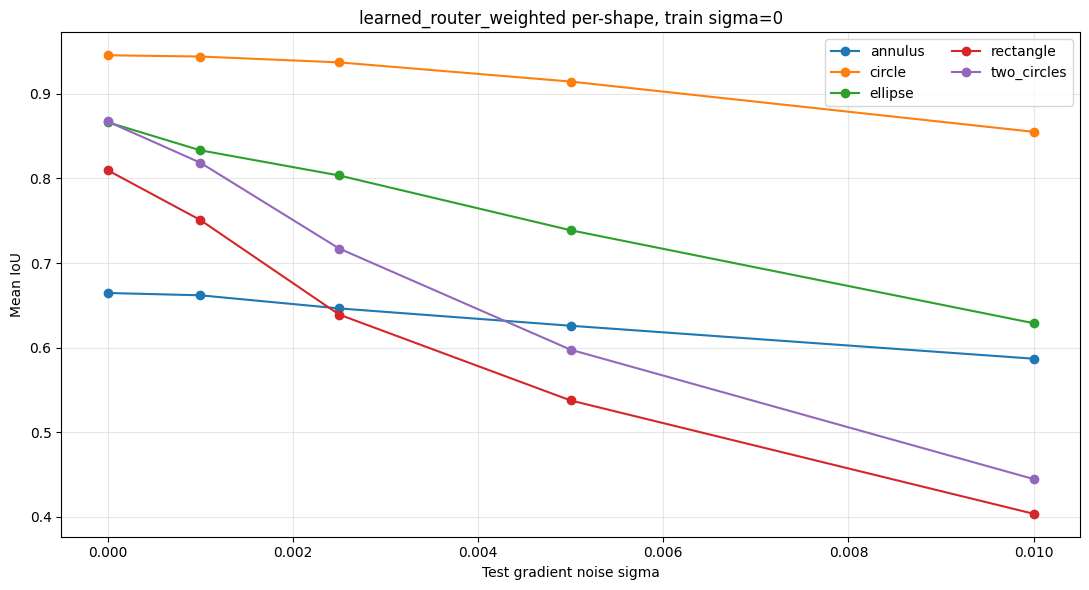


=== train sigma=0.001, condition=learned_router ===


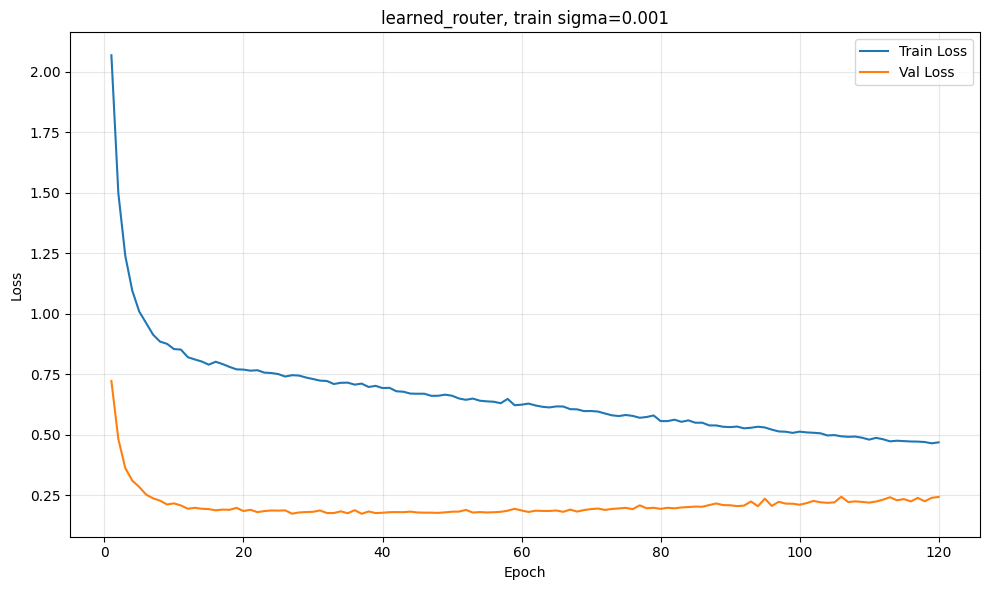

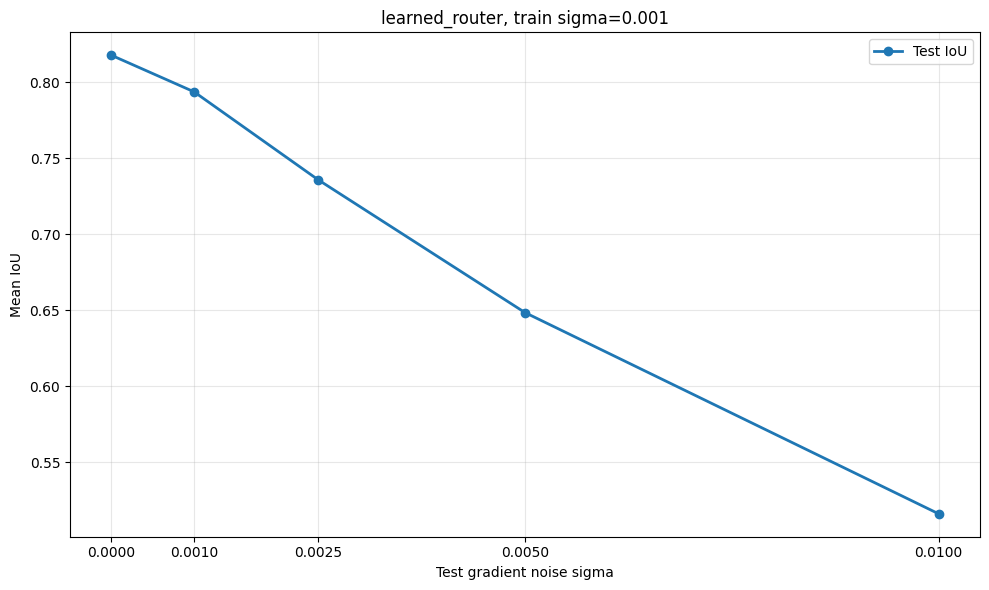

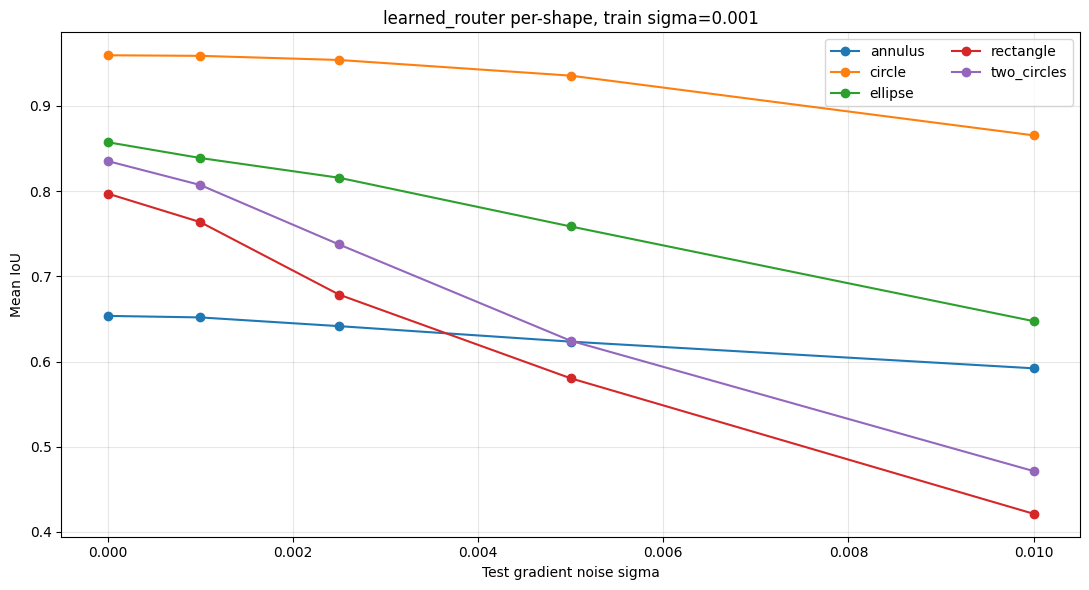


=== train sigma=0.001, condition=learned_router_weighted ===


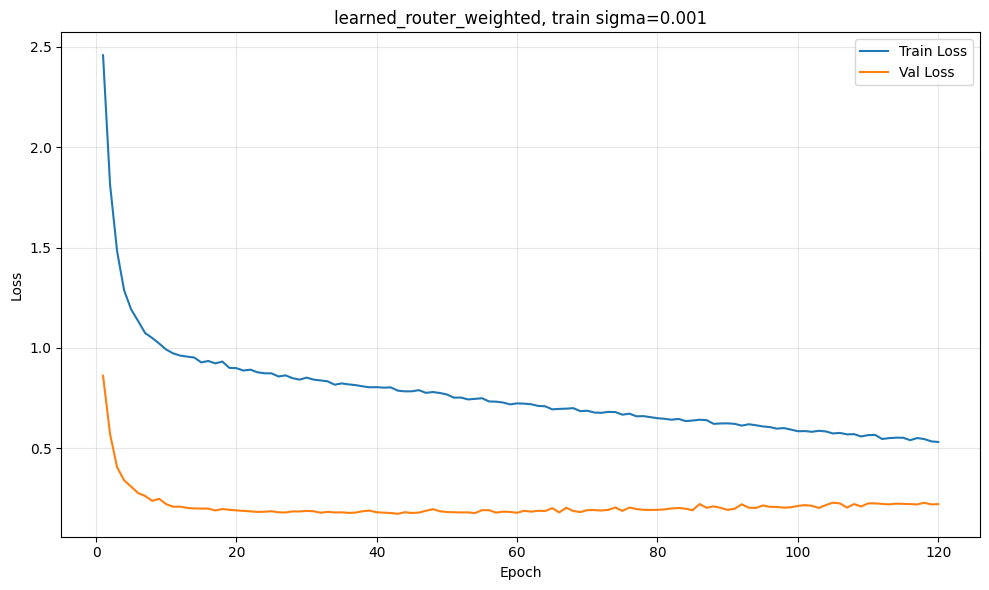

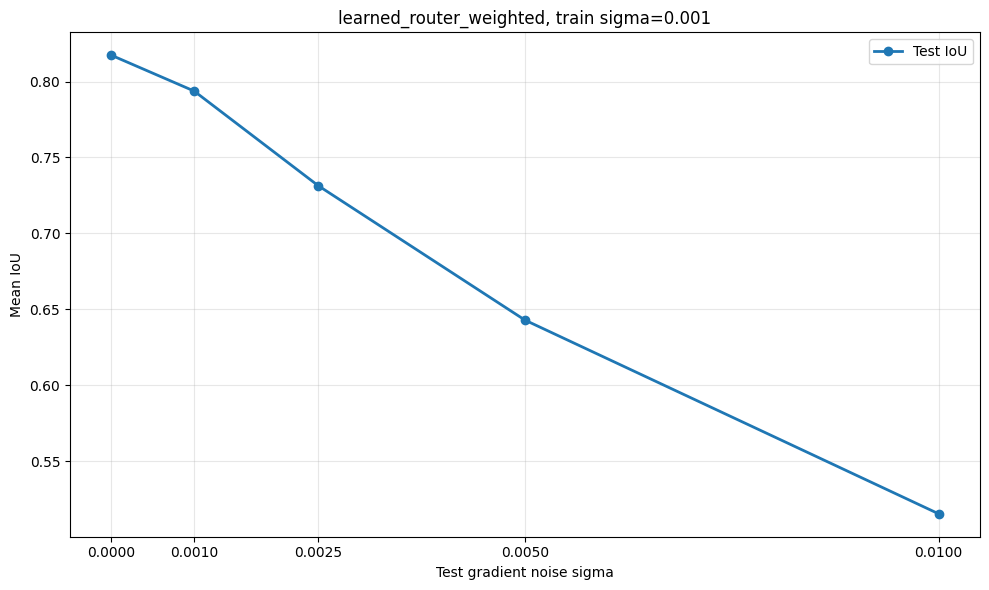

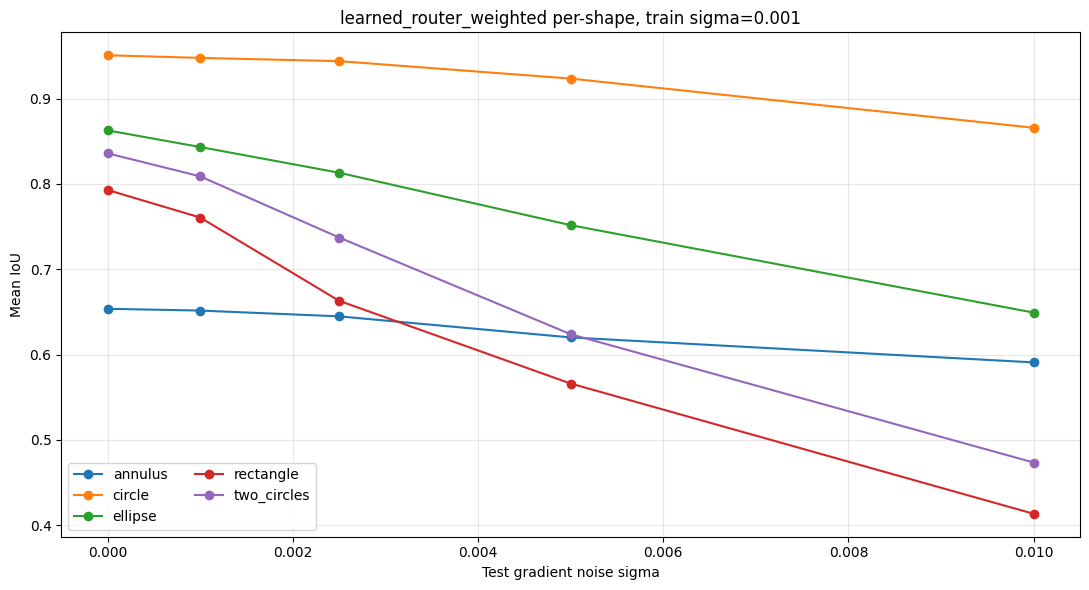


=== train sigma=0.0025, condition=learned_router ===


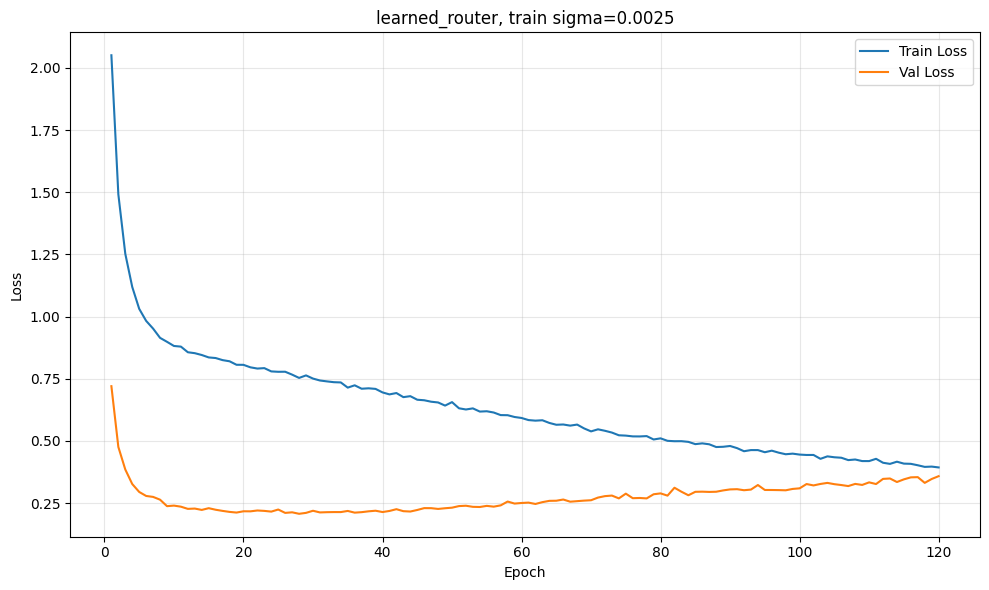

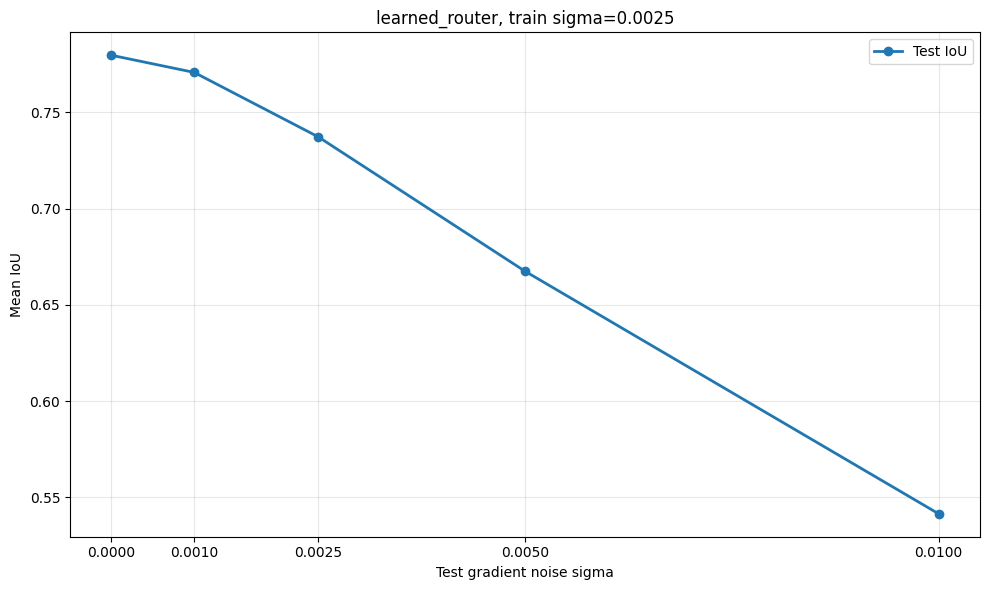

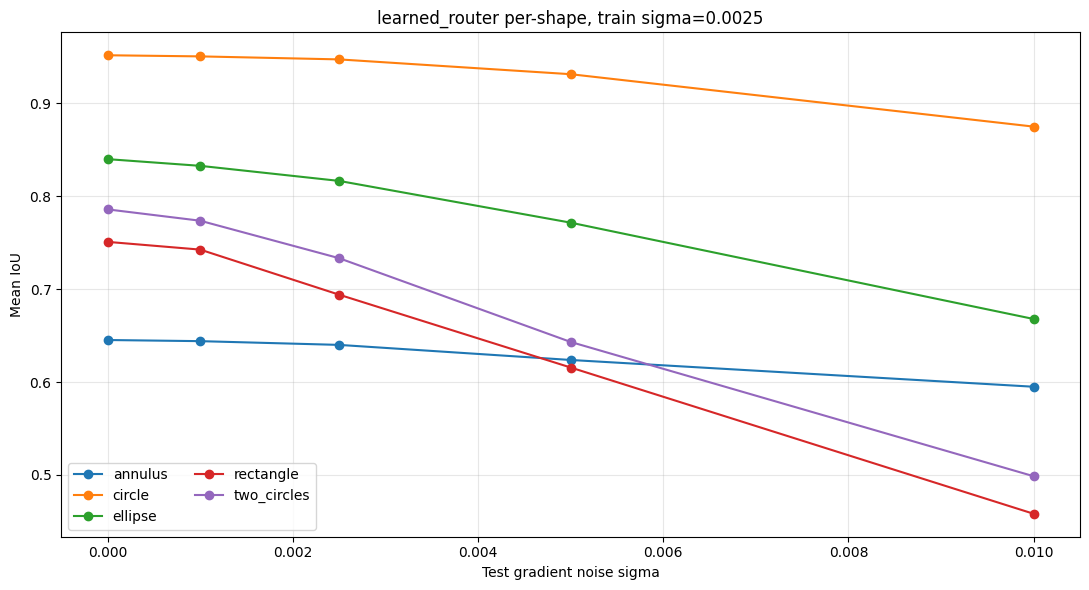


=== train sigma=0.0025, condition=learned_router_weighted ===


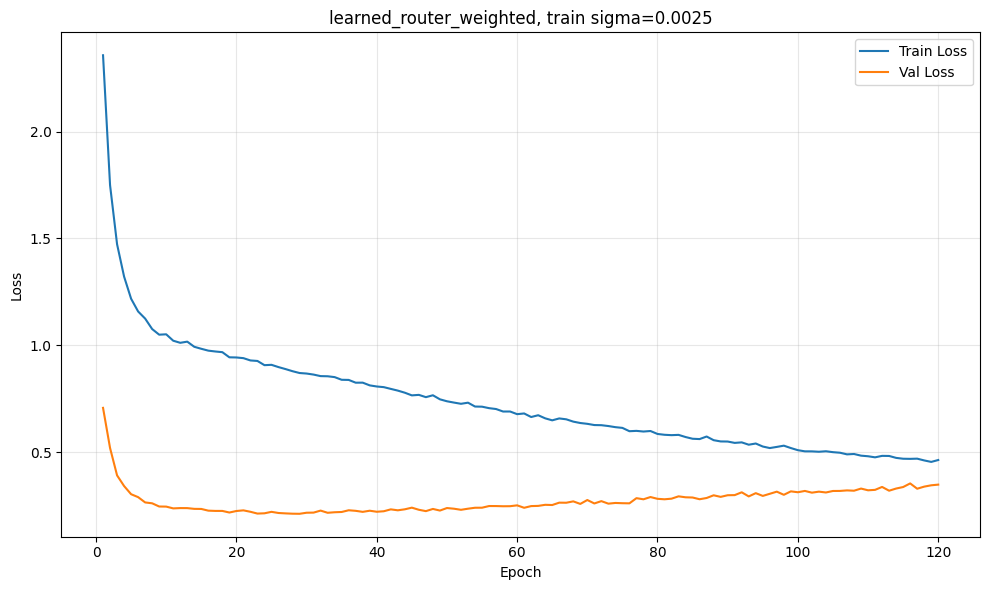

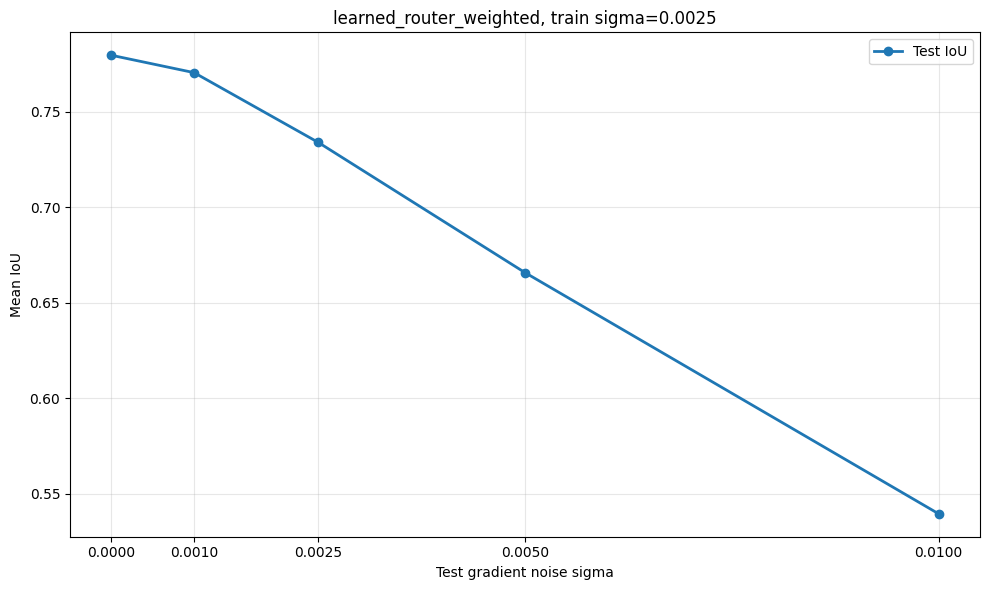

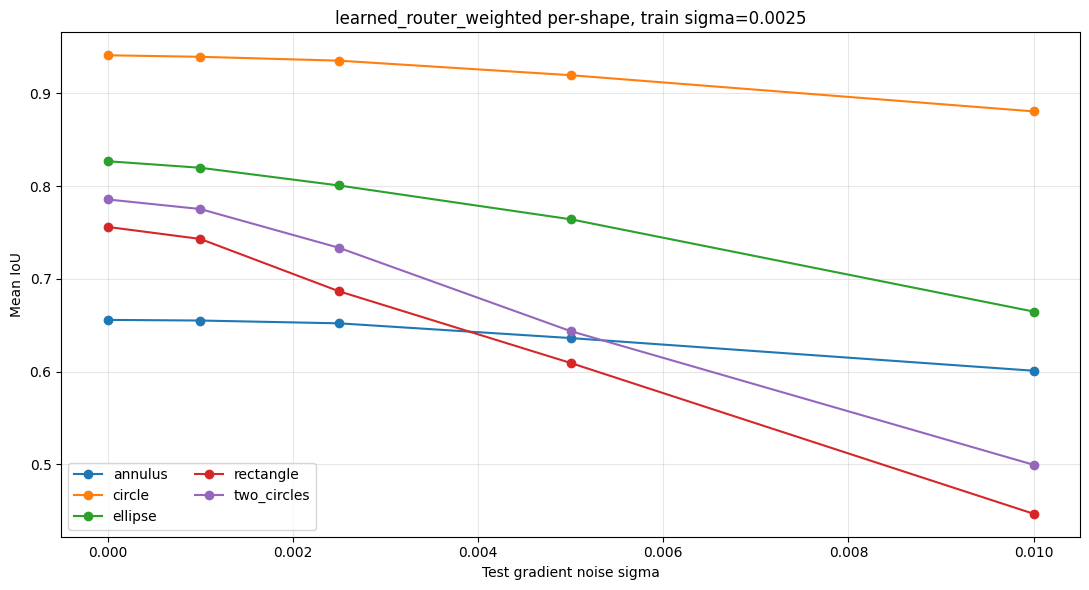


=== train sigma=0.005, condition=learned_router ===


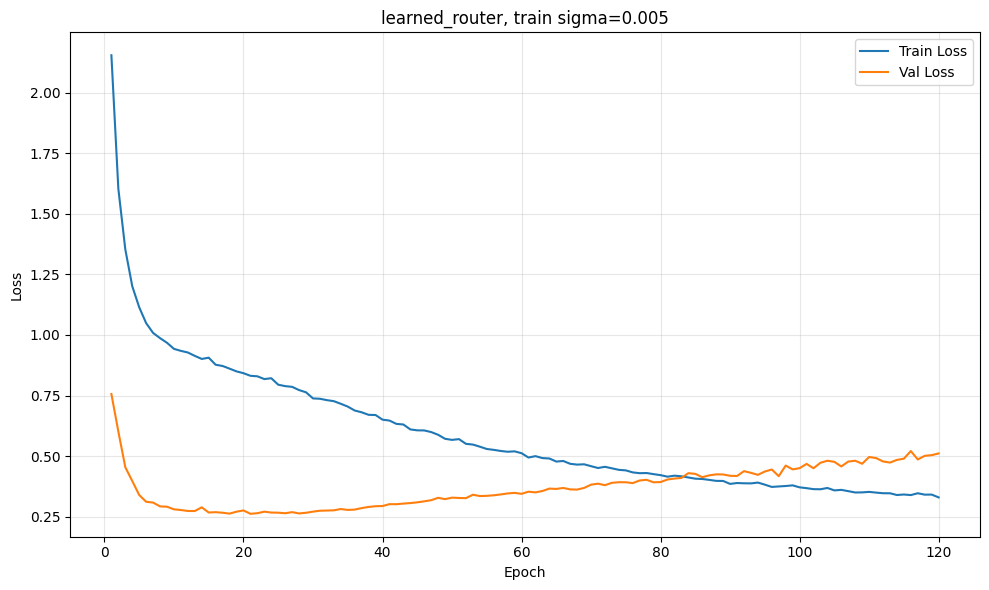

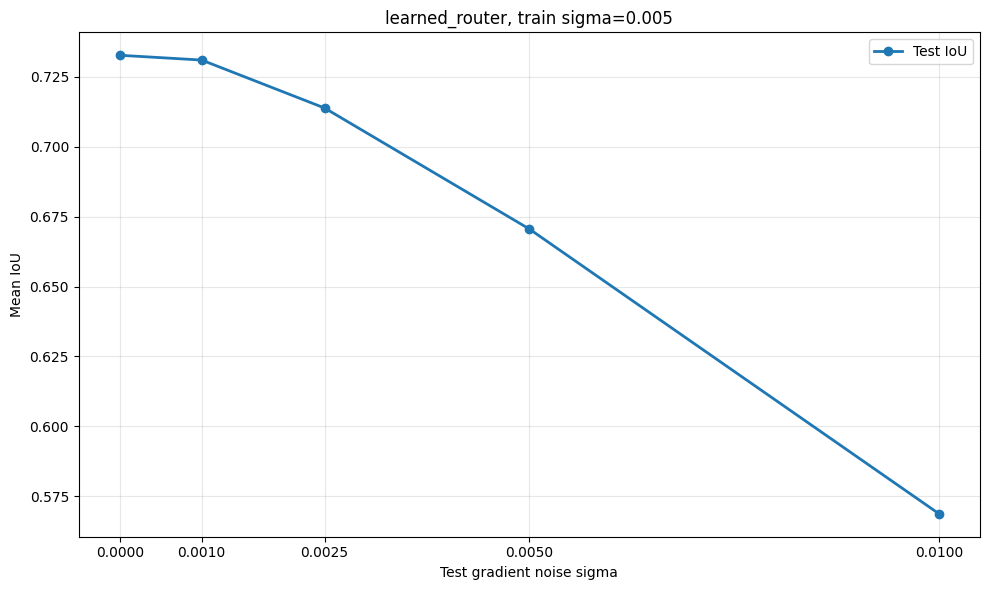

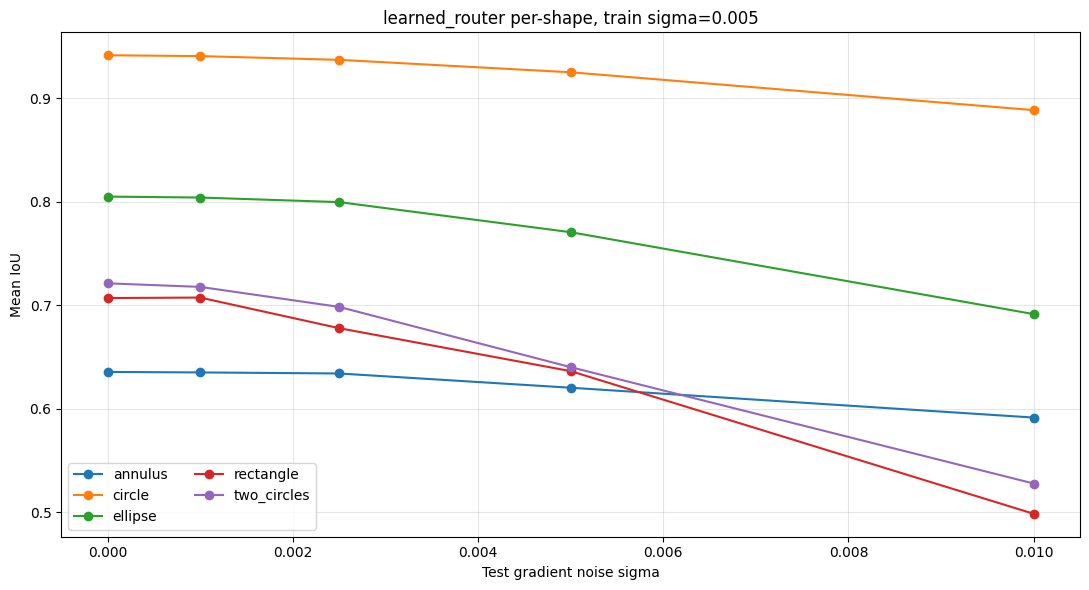


=== train sigma=0.005, condition=learned_router_weighted ===


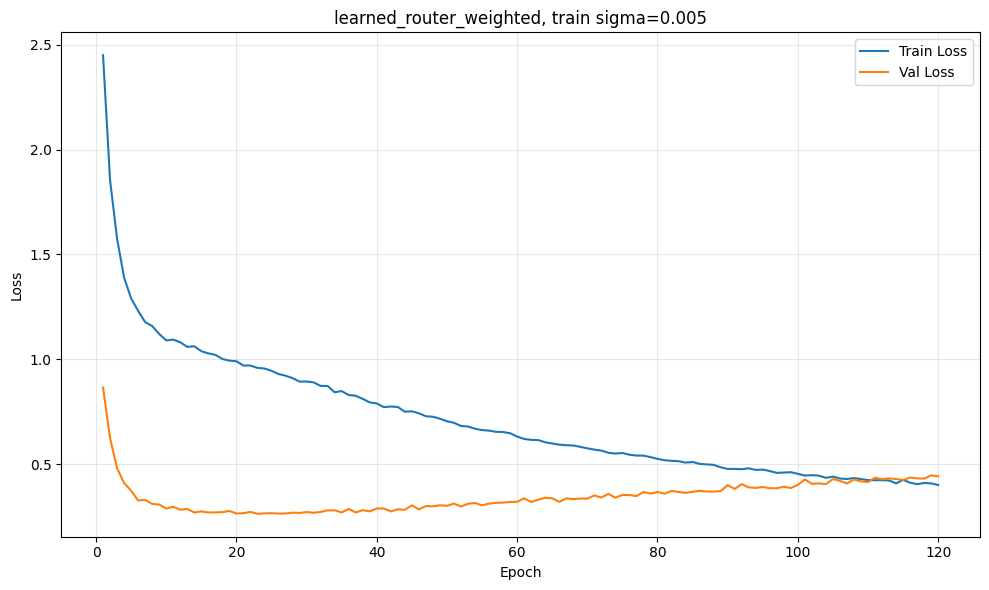

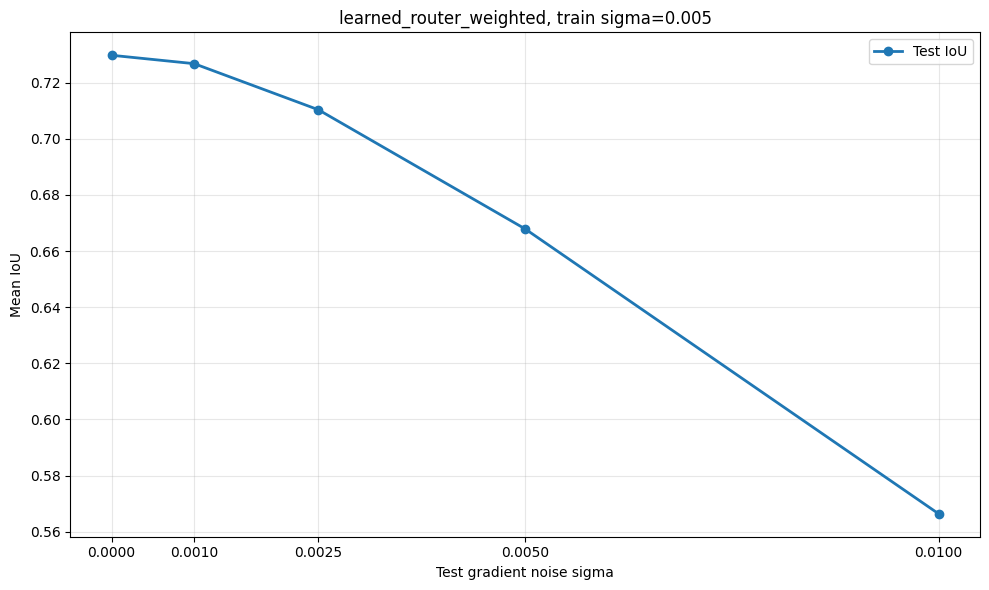

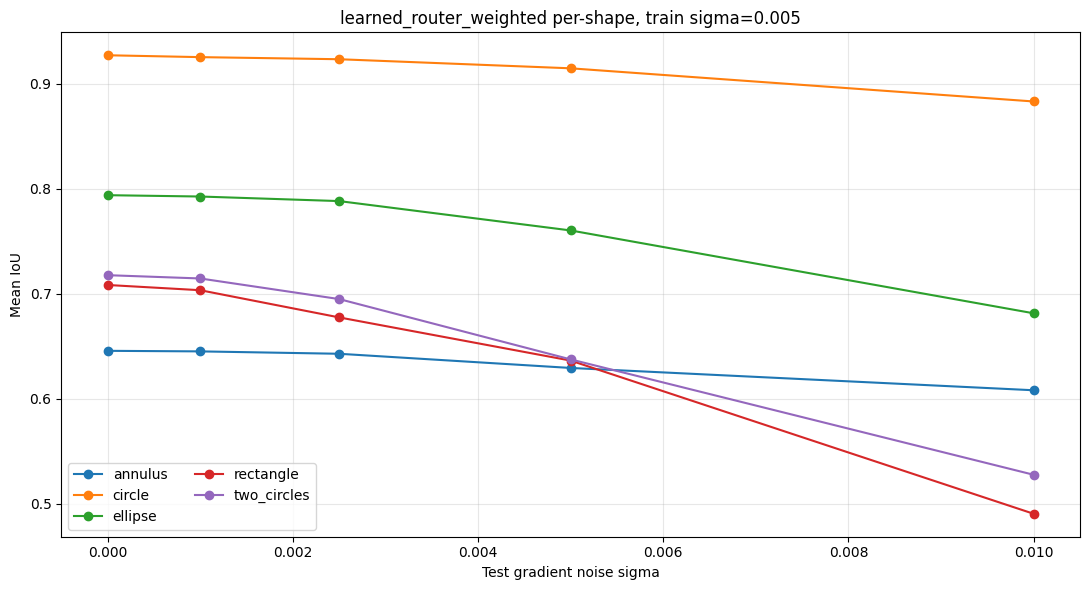


=== train sigma=0.01, condition=learned_router ===


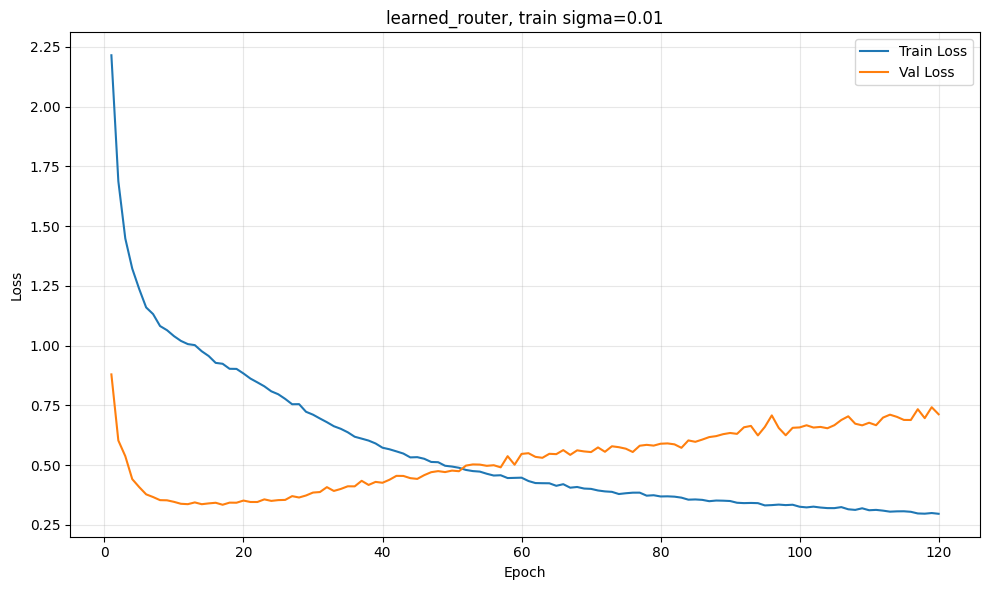

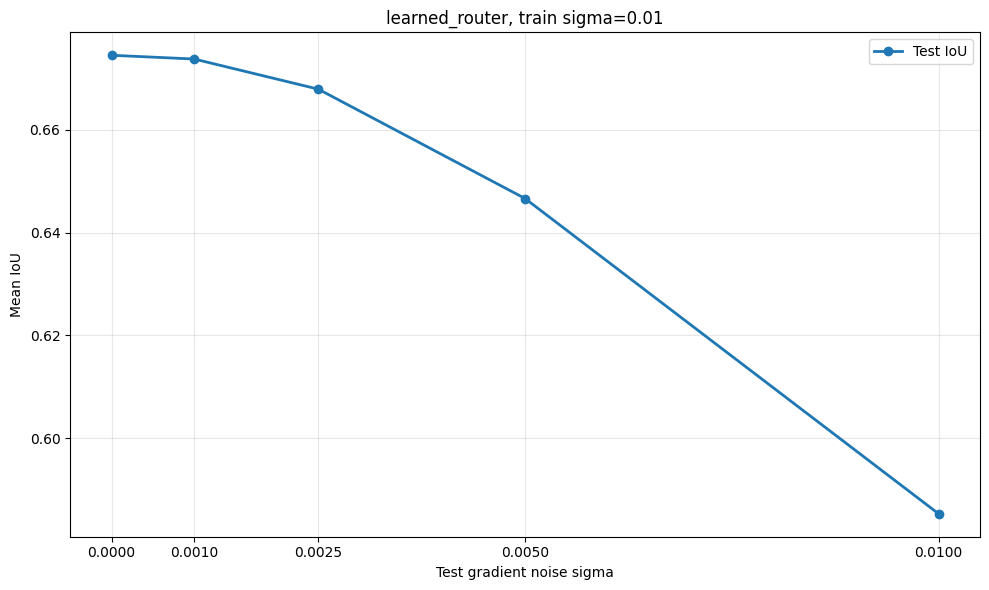

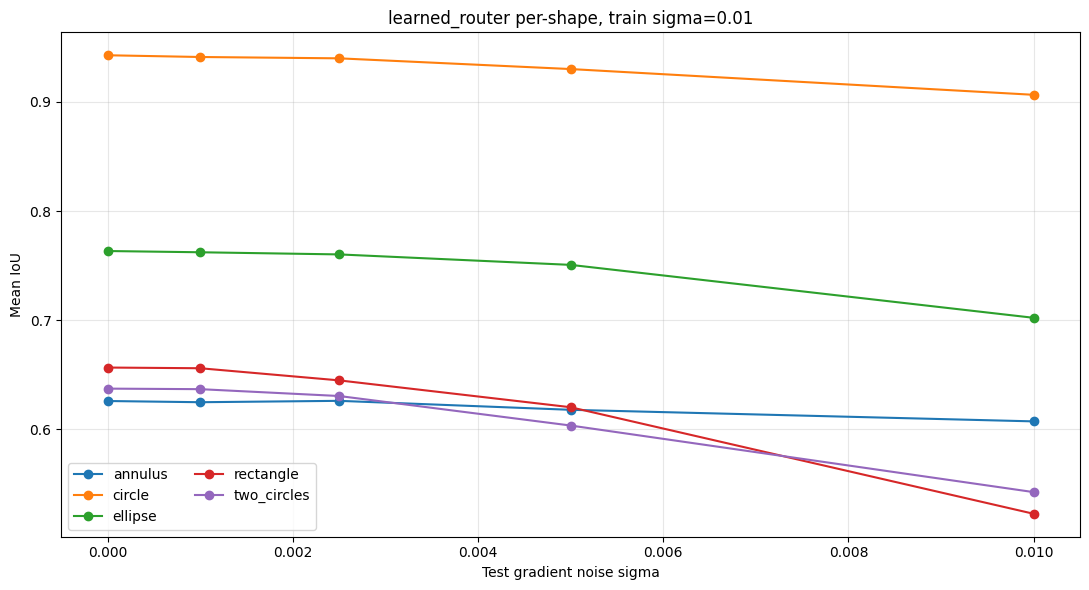


=== train sigma=0.01, condition=learned_router_weighted ===


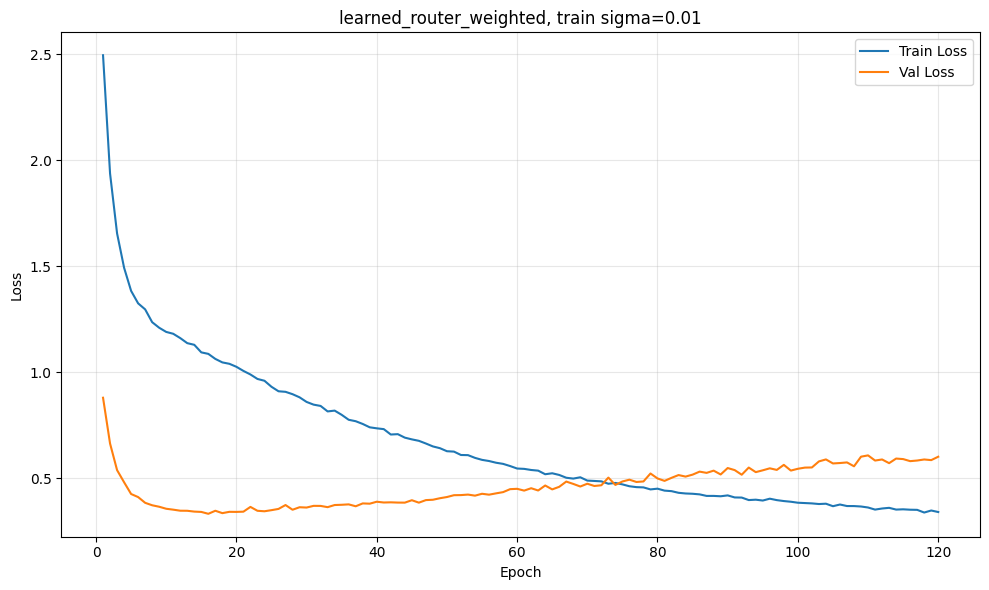

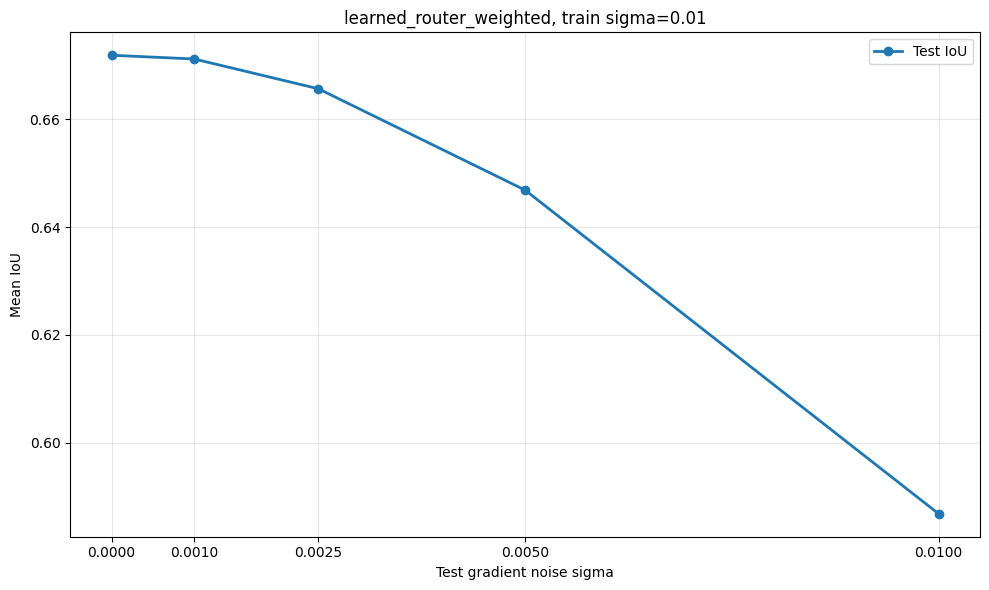

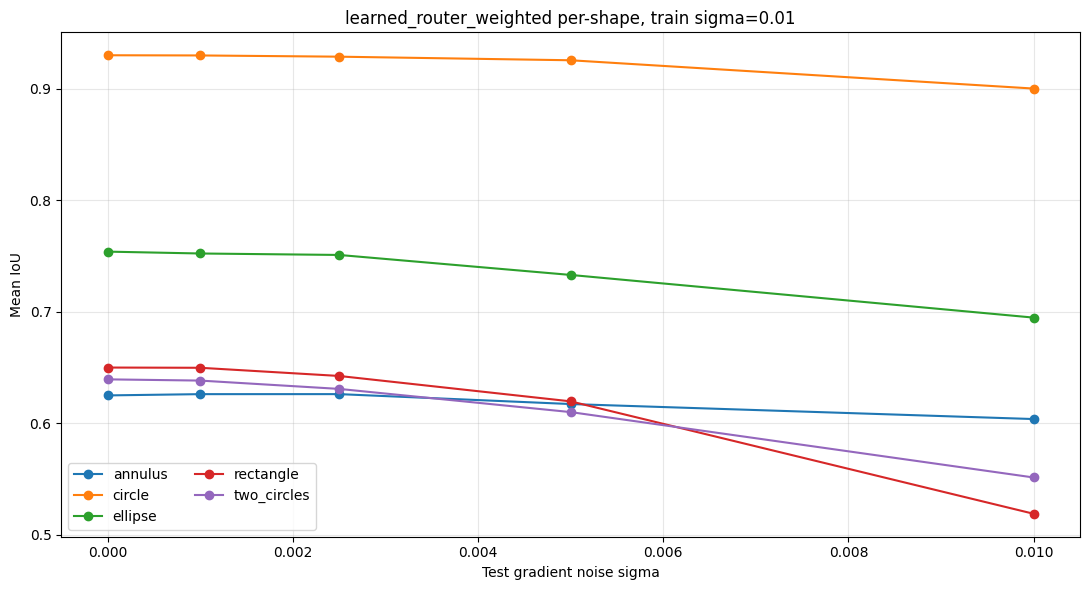

,train_sigma,condition,clean_test_iou,clean_annulus_iou,router_accuracy,router_precision,router_recall,threshold
0,0.0000,learned_router,0.840922,0.651555,0.853,0.355030,0.612245,0.50
1,0.0000,learned_router_weighted,0.837311,0.664595,0.853,0.356725,0.622449,0.50
2,0.0010,learned_router,0.817859,0.653611,0.844,0.338889,0.622449,0.50
3,0.0010,learned_router_weighted,0.817316,0.653721,0.850,0.350575,0.622449,0.55
4,0.0025,learned_router,0.779669,0.645193,0.854,0.357143,0.612245,0.50
5,0.0025,learned_router_weighted,0.779658,0.655844,0.840,0.333333,0.632653,0.50
6,0.0050,learned_router,0.732730,0.635732,0.856,0.359756,0.602041,0.55
7,0.0050,learned_router_weighted,0.729797,0.645518,0.843,0.337017,0.622449,0.50
8,0.0100,learned_router,0.674497,0.625950,0.852,0.352941,0.612245,0.55
9,0.0100,learned_router_weighted,0.671862,0.625048,0.835,0.328205,0.653061,0.45


In [2]:
def train_or_load(config, annulus_edge_weight):
    condition_dir = config.output_dir
    model_path = condition_dir / 'annulus_router_model.pt'
    summary_path = condition_dir / 'summary.json'
    bundle = build_two_stage_datasets(config)
    model = make_model(config)
    if RUN_TRAINING or not summary_path.exists():
        result = fit_annulus_router(model, bundle.train.gradient_data, bundle.train.masks, bundle.train.shape_types, bundle.validation.gradient_data, bundle.validation.masks, epochs=120, batch_size=96, learning_rate=0.0005, device=DEVICE, router_loss_weight=0.25, specialist_loss_weight=1.0, annulus_edge_weight=annulus_edge_weight, annulus_edge_width=3, grid_size=config.grid_size)
        validation_logits = predict_annulus_router(model, bundle.validation.gradient_data, device=DEVICE, training_result=result)
        threshold_summary = select_best_stage2_threshold(bundle.validation.masks, validation_logits, config.threshold_candidates)
        summary = {'config': {'train_sigma': config.noise_sigma, 'condition': condition_dir.name}, 'threshold_summary': threshold_summary, 'training_history': result.history, 'training_input_mean': result.input_mean.tolist(), 'training_input_std': result.input_std.tolist()}
        condition_dir.mkdir(parents=True, exist_ok=True)
        torch.save(model.state_dict(), model_path)
        summary_path.write_text(json.dumps(summary, indent=2), encoding='utf-8')
    else:
        summary = json.loads(summary_path.read_text(encoding='utf-8'))
        result = type('RouterResult', (), {'history': summary['training_history'], 'input_mean': np.asarray(summary['training_input_mean'], dtype=np.float32), 'input_std': np.asarray(summary['training_input_std'], dtype=np.float32)})()
        model.load_state_dict(torch.load(model_path, map_location=DEVICE, weights_only=True))
    return bundle, model, result, float(summary['threshold_summary']['selected_threshold']), summary

results = []
for train_sigma in TRAIN_SIGMAS:
    for condition, annulus_edge_weight in CONDITIONS.items():
        config = make_config(train_sigma, condition)
        print(f'\n=== train sigma={train_sigma:g}, condition={condition} ===')
        bundle, model, result, threshold, summary = train_or_load(config, annulus_edge_weight)
        predict = lambda features, m=model, r=result: predict_annulus_router(m, features, device=DEVICE, training_result=r)
        overall, by_shape = evaluate_noise_sweep(predict, bundle.test.gradient_data, bundle.test.masks, bundle.test.shape_types, threshold, noise_levels=TEST_SIGMAS, seed=42)
        save_noise_results(overall, by_shape, config.output_dir, stem='test_noise_robustness')
        plot_history(summary['training_history'], config.output_dir / 'training_curves.png', f'{condition}, train sigma={train_sigma:g}')
        plot_noise_curve(overall, config.output_dir / 'test_noise_curve.png', f'{condition}, train sigma={train_sigma:g}')
        plot_shape_curves(by_shape, config.output_dir / 'test_noise_by_shape.png', f'{condition} per-shape, train sigma={train_sigma:g}')
        _clean_logits, router_logits = predict_annulus_router(model, bundle.test.gradient_data, device=DEVICE, training_result=result, return_router_logits=True)
        true_annulus = np.asarray([shape == 'annulus' for shape in bundle.test.shape_types])
        predicted_annulus = router_logits >= 0.0
        true_positive = np.sum(predicted_annulus & true_annulus)
        router_accuracy = float(np.mean(predicted_annulus == true_annulus))
        router_precision = float(true_positive / max(np.sum(predicted_annulus), 1))
        router_recall = float(true_positive / max(np.sum(true_annulus), 1))
        clean = overall[overall['noise_sigma'] == 0.0].iloc[0]
        annulus = by_shape[(by_shape['noise_sigma'] == 0.0) & (by_shape['shape'] == 'annulus')].iloc[0]
        results.append({'train_sigma': train_sigma, 'condition': condition, 'clean_test_iou': clean['mean_iou'], 'clean_annulus_iou': annulus['mean_iou'], 'router_accuracy': router_accuracy, 'router_precision': router_precision, 'router_recall': router_recall, 'threshold': threshold})
comparison = pd.DataFrame(results).sort_values(['train_sigma', 'clean_test_iou'], ascending=[True, False])
comparison.to_csv(OUTPUT / 'router_comparison.csv', index=False)
display(comparison)

## Promotion rule

Promote the router only if annulus IoU improves without materially reducing overall IoU or other-shape IoU. Router accuracy alone is not sufficient because annulus is a minority class. The clean `test_sigma000` result is official; other test-sigma directories are supplementary robustness results.